# wyrm2 local models vs the frontier — measured + eval comparison

Two kinds of data, kept clearly separate:

- **Measured here** (`local`): tokens/s, context we can actually run, VRAM —
  from the E1–E5 runs on 2×RTX 5090 (`cluster/docs/inference/runs/`).
- **Third-party evals** (`ext`): SWE-bench Verified, GPQA, AIME, LiveCodeBench —
  pulled from vendor cards and independent leaderboards (July 2026). Every number
  carries a source URL in `SOURCES` below.

**Big caveat on eval comparability.** SWE-bench Verified numbers mix vendor
self-reports (which vary by agent scaffold, e.g. OpenHands N-turns) with
independent leaderboards (vals.ai). They are **not** strictly comparable — treat
±several points as noise, and read the trend, not the decimal. Anchor numbers for
the very newest closed models had conflicting web reports; the shakier ones are
omitted or flagged rather than guessed.

**Reasoning-effort caveat (the speed×quality plot isn't strictly apples-to-apples).**
Reasoning models spend a variable, usually large, number of thinking tokens per
answer. So (a) `decode tok/s` is *not* answers/s — a reasoner at 200 tok/s that
emits 2000 thinking tokens is far slower per task than a direct model at 200 tok/s;
and (b) most published eval scores are at *high* reasoning effort (more tokens →
higher score), a cost the speed axis doesn't show. A stricter version would use
tokens-per-task / answers-per-hour at a fixed effort. Left as future work.

In [1]:
from dataclasses import dataclass, field

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

plt.rcParams.update({"figure.dpi": 120, "font.size": 10, "axes.grid": True, "grid.alpha": 0.3})

# --- source URLs (reproducible links) -----------------------------------------
SOURCES = {
    "qwen3coder": "https://huggingface.co/Qwen/Qwen3-Coder-30B-A3B-Instruct",
    "gptoss": "https://arxiv.org/abs/2508.10925",  # OpenAI gpt-oss model card
    "qwen35": "https://huggingface.co/Qwen/Qwen3.5-35B-A3B",
    "devstral": "https://mistral.ai/news/devstral-2-vibe-cli/",
    "valsai_swe": "https://www.vals.ai/benchmarks/swebench",  # independent, dated 2026-07-17
    "gpt5": "https://openai.com/index/introducing-gpt-5/",
    "sonnet45": "https://www.anthropic.com/news/claude-sonnet-4-5",
    "runs": "cluster/docs/inference/runs/  (E1–E5, measured on 2×5090)",
    "glm52": "https://venturebeat.com/technology/z-ais-open-weights-glm-5-2-beats-gpt-5-5-on-multiple-long-horizon-coding-benchmarks-for-1-6th-the-cost",
    "glm52_colibri": "cluster/docs/inference/runs/2026-07-14_glm52_colibri/  (measured 0.28 tok/s)",
    "oss120": "https://arxiv.org/abs/2508.10925",  # same gpt-oss card (120b rows)
}

In [2]:
# --- MEASURED on 2×5090 (local) ------------------------------------------------
@dataclass
class Measured:
    label: str
    runtime: str
    # decode tokens/s at input context (K tokens) -> tok/s
    decode: dict = field(default_factory=dict)
    allocated_ctx_k: float = 0.0  # largest context that loads + completes (K tokens)
    vram_gb: float = 0.0  # peak, per GPU (max of the two)
    tools: str = ""  # tool-calling smoke result
    note: str = ""


MEASURED = [
    Measured("Qwen3-Coder-30B", "vLLM TP2 AWQ", {8: 271, 32: 235, 128: 199}, 262, 30.7, "single+parallel+multi ✓"),
    Measured("gpt-oss-20b (vLLM)", "vLLM TP1 MXFP4", {8: 1356, 32: 1035, 128: 1494}, 128, 15.0, "parallel ✗ (model)"),
    Measured("gpt-oss-20b (Ollama)", "Ollama GGUF", {8: 1154, 32: 917, 128: 636}, 128, 15.0, "parallel ✗ (model)"),
    Measured("Qwen3.5-35B-A3B", "vLLM TP2 FP8 (GDN)", {8: 231, 32: 226, 128: 211}, 262, 29.0, "✗ hermes parser"),
    Measured("Devstral-24B", "vLLM TP2 FP8 dense", {8: 96, 32: 89}, 128, 30.7, "single+parallel+multi ✓"),
    Measured("Qwen2.5-7B-1M", "vLLM TP2", {}, 0, 0.0, note="1M blocked: DCA has no sm_120 kernel"),
]

# --- THIRD-PARTY EVALS (ext) ---------------------------------------------------
# SWE-bench Verified — the one eval with coverage across all our models + anchors.
# (score, source_key, kind)  kind: "resident" = fits our 64 GB VRAM;
# "offload" = we can run it but only via CPU/RAM/disk offload (slow);
# "anchor" = closed frontier reference we cannot run.
SWEBENCH = {
    "Qwen3-Coder-30B": (51.9, "qwen3coder", "resident"),
    "gpt-oss-20b": (60.7, "gptoss", "resident"),  # high reasoning effort
    "Devstral-24B": (68.0, "devstral", "resident"),
    "Qwen3.5-35B-A3B": (69.2, "qwen35", "resident"),
    "gpt-oss-120b": (62.4, "oss120", "offload"),  # runs on Ollama CPU-offload
    "GLM-5.2 (744B)": (77.8, "glm52", "offload"),  # ran on Colibri disk-streamed
    "Claude Sonnet 4.5": (77.2, "sonnet45", "anchor"),  # 82.0 w/ parallel compute
    "Gemini 3.5 Flash": (78.8, "valsai_swe", "anchor"),
    "GPT-5.5": (82.6, "valsai_swe", "anchor"),
    "Claude Opus 4.8": (88.6, "valsai_swe", "anchor"),
    "Claude Fable 5": (95.0, "valsai_swe", "anchor"),
}

# Runnable models (resident + offload) placed in measured-speed × SWE-bench space.
# decode tok/s is what WE measured; offload models are 100–5000× slower.
# label: (measured decode tok/s, swe_bench %, kind)
RUNNABLE_QUALITY = {
    "gpt-oss-20b": (1300, 60.7, "resident"),
    "Qwen3-Coder-30B": (199, 51.9, "resident"),
    "Qwen3.5-35B-A3B": (211, 69.2, "resident"),
    "Devstral-24B": (92, 68.0, "resident"),
    "gpt-oss-120b": (1.5, 62.4, "offload"),  # Ollama CPU offload (~1.5 tok/s)
    "GLM-5.2 (744B)": (0.28, 77.8, "offload"),  # Colibri disk-streamed experts
}
OFFLOAD_COLOR = "#16a085"

# Reasoning-eval coverage (only models that report them; coding specialists mostly don't).
# metric -> {model: value}
REASONING = {
    "GPQA Diamond": {
        "gpt-oss-20b": 71.5,
        "gpt-oss-120b": 80.9,
        "Qwen3.5-35B-A3B": 84.2,
        "Claude Sonnet 4.5": 83.4,
        "GPT-5": 88.4,
    },
    "AIME 2025": {  # gpt-oss & GPT-5/Sonnet without-tools where noted
        "gpt-oss-20b": 98.7,  # with tools
        "gpt-oss-120b": 92.5,  # high, no tools
        "Qwen3.5-35B-A3B": 93.3,  # AIME'26 (card doesn't split; treat as recent-AIME)
        "Claude Sonnet 4.5": 87.0,  # without tools
        "GPT-5": 94.6,  # without tools
    },
    "LiveCodeBench": {  # v6 for Qwen3.5; others report varying versions — sparse
        "Qwen3.5-35B-A3B": 74.6,
    },
}

LOCAL_COLOR, ANCHOR_COLOR = "#2a7fff", "#c0392b"

# Reasoning behaviour. In 2026 reasoning-with-an-effort-dial (low→high / thinking
# budget) is near-universal — Claude, Gemini, GPT-5, gpt-oss, Qwen3.5 all have it;
# it's a continuous control, not an on/off switch. The genuine exceptions are the
# few models *shipped without* a thinking mode (e.g. Qwen3-Coder). What still
# varies enormously is how many reasoning tokens a model spends by default
# (Qwen3.5 was extremely verbose in E4). category: Reasoning | Direct.
# model -> (category, kind, basis)
REASONING_CLASS = {
    "Qwen3-Coder-30B": ("Direct", "local", "shipped without a thinking mode (Qwen)"),
    "Devstral-24B": ("Direct", "local", "answered directly, no CoT in E5"),
    "gpt-oss-20b": ("Reasoning", "local", "reasoning_effort low/med/high (E2)"),
    "Qwen3.5-35B-A3B": ("Reasoning", "local", "verbose CoT, effort dial (E4)"),
    "Claude Sonnet 4.5": ("Reasoning", "anchor", "reasoning effort / thinking budget"),
    "Claude Opus 4.8": ("Reasoning", "anchor", "reasoning effort"),
    "Gemini 3.5 Flash": ("Reasoning", "anchor", "thinking budget"),
    "GPT-5": ("Reasoning", "anchor", "reasoning effort"),
}

## 1. Decode throughput we can actually get (measured)

Tokens/s tracks **active parameters**: the small-active MoEs fly, the dense 24B
crawls. Ollama vs vLLM shown for gpt-oss (runtime matters, esp. at long context).

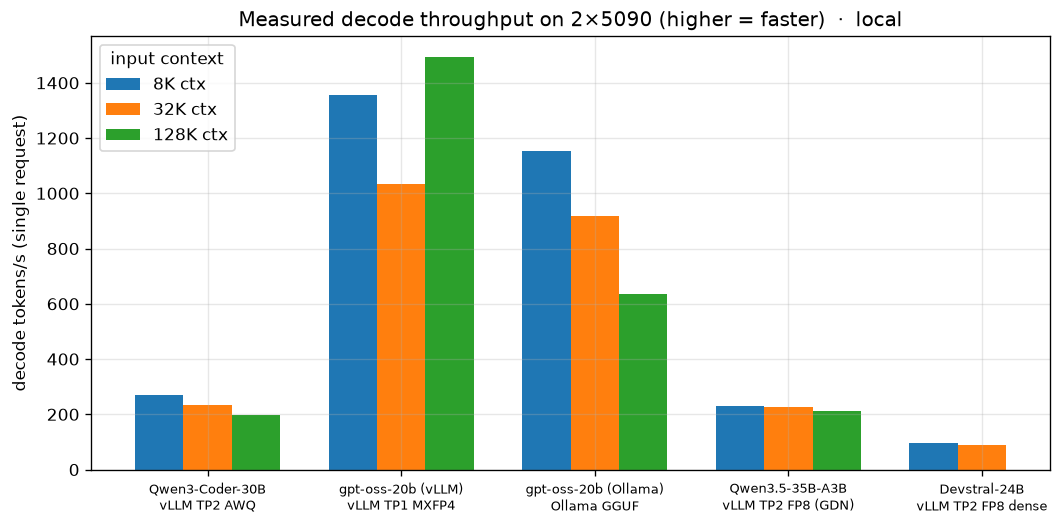

In [3]:
fig, ax = plt.subplots(figsize=(9, 4.5))
runnable = [m for m in MEASURED if m.decode]
ctxs = [8, 32, 128]
x = np.arange(len(runnable))
w = 0.25
for i, c in enumerate(ctxs):
    vals = [m.decode.get(c, np.nan) for m in runnable]
    ax.bar(x + (i - 1) * w, vals, w, label=f"{c}K ctx")
ax.set_xticks(x)
ax.set_xticklabels([f"{m.label}\n{m.runtime}" for m in runnable], fontsize=8)
ax.set_ylabel("decode tokens/s (single request)")
ax.set_title("Measured decode throughput on 2×5090 (higher = faster)  ·  local")
ax.legend(title="input context")
fig.tight_layout()
fig.savefig("fig1_decode_tps.png", bbox_inches="tight")

## 1b. Reasoning vs direct models

In 2026 **reasoning with a low→high effort dial is near-universal** — Claude,
Gemini, GPT-5, gpt-oss, and Qwen3.5 all have it; nobody trains it as a plain
on/off button. So the interesting split isn't "reasoning vs not" but the handful
of models **shipped without a thinking mode at all** (a couple of purpose-built
coding models). Orthogonal, and what actually bites latency: *how many* reasoning
tokens a model spends by default — Qwen3.5 was extremely verbose in E4.

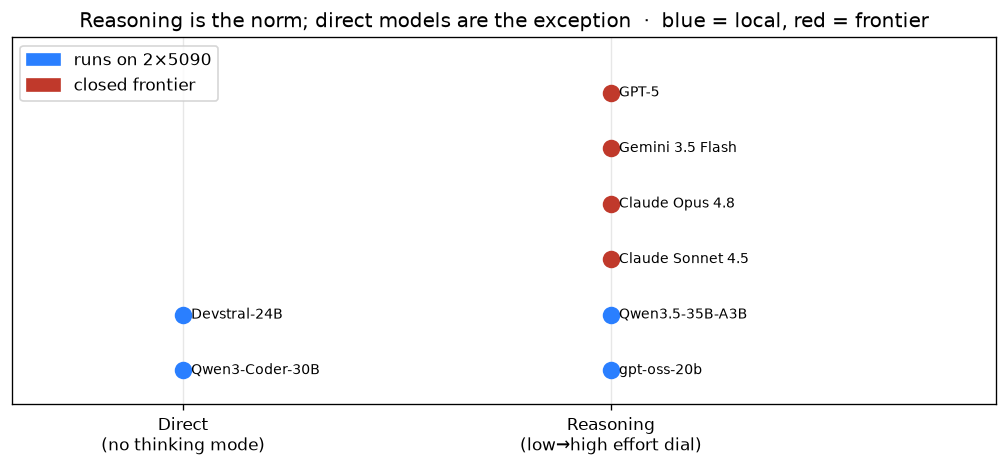

In [4]:
fig, ax = plt.subplots(figsize=(8.5, 4))
cat_x = {"Direct": 0, "Reasoning": 1}
col_counts = {c: 0 for c in cat_x}
for name, (cat, kind, basis) in REASONING_CLASS.items():
    y = col_counts[cat]
    col_counts[cat] += 1
    color = LOCAL_COLOR if kind == "local" else ANCHOR_COLOR
    ax.scatter(cat_x[cat], y, s=90, color=color, zorder=3)
    ax.annotate(f"  {name}", (cat_x[cat], y), va="center", fontsize=8.5)
ax.set_xticks(list(cat_x.values()))
ax.set_xticklabels(["Direct\n(no thinking mode)", "Reasoning\n(low→high effort dial)"])
ax.set_xlim(-0.4, 1.9)
ax.set_ylim(-0.6, max(col_counts.values()))
ax.set_yticks([])
ax.set_title("Reasoning is the norm; direct models are the exception  ·  blue = local, red = frontier")
ax.legend(handles=[Patch(color=LOCAL_COLOR, label="runs on 2×5090"), Patch(color=ANCHOR_COLOR, label="closed frontier")], loc="upper left")
fig.tight_layout()
fig.savefig("fig1b_reasoning_class.png", bbox_inches="tight")

## 2. Context window we can run (measured allocated context)

Practical ceiling today is ~256K. The 1M attempt is **blocked by kernels, not
memory** (dual-chunk attention has no Blackwell/sm_120 build in vLLM 0.25.1).
Log x-axis so the 128K/262K models and the 1M target sit on a comparable scale.

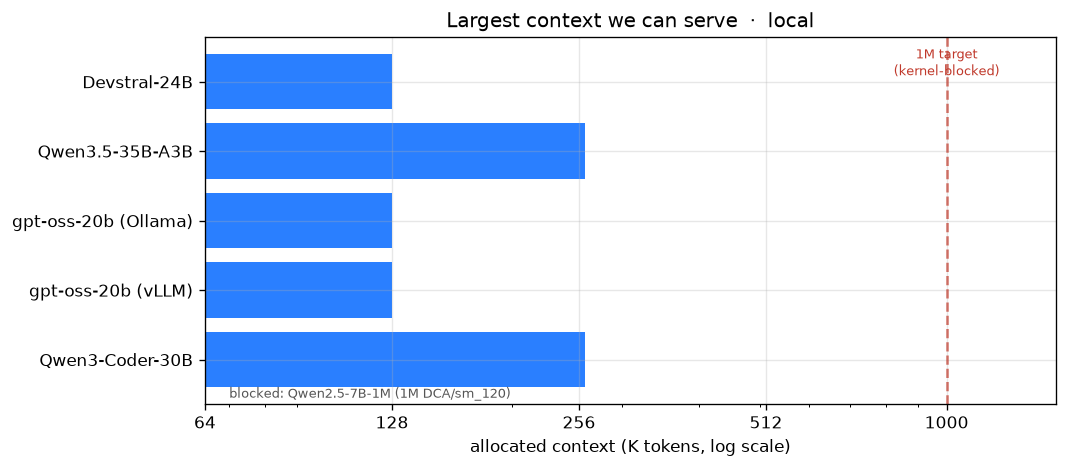

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
runnable_ctx = [m for m in MEASURED if m.allocated_ctx_k > 0]
ax.barh([m.label for m in runnable_ctx], [m.allocated_ctx_k for m in runnable_ctx], color=LOCAL_COLOR)
ax.set_xscale("log")
ax.set_xlim(64, 1500)
ax.set_xticks([64, 128, 256, 512, 1000])
ax.get_xaxis().set_major_formatter(plt.matplotlib.ticker.ScalarFormatter())
ax.set_xlabel("allocated context (K tokens, log scale)")
ax.set_title("Largest context we can serve  ·  local")
ax.axvline(1000, ls="--", color=ANCHOR_COLOR, alpha=0.7)
ax.text(1000, len(runnable_ctx) - 0.5, "1M target\n(kernel-blocked)", color=ANCHOR_COLOR, fontsize=8, ha="center", va="top")
blocked = [m for m in MEASURED if m.allocated_ctx_k == 0]
if blocked:
    ax.text(70, -0.55, "blocked: " + ", ".join(m.label for m in blocked) + " (1M DCA/sm_120)", fontsize=8, color="#555")
fig.tight_layout()
fig.savefig("fig2_context.png", bbox_inches="tight")

## 3. SWE-bench Verified — local models vs the frontier

The one eval everyone reports. Blue = we can run it locally; red = closed
frontier reference. Mind the comparability caveat (self-report vs leaderboard).

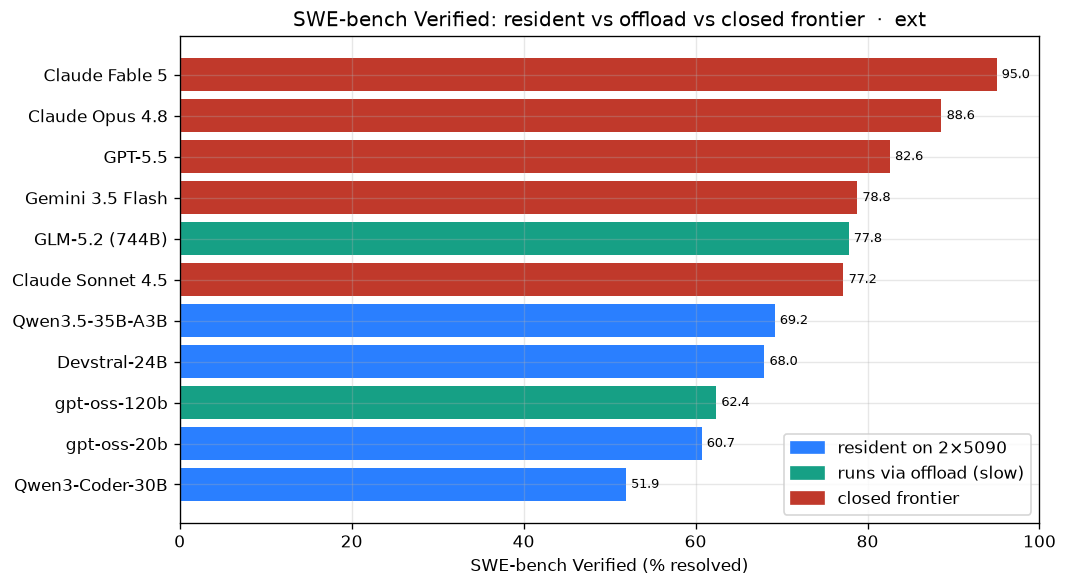

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
kind_color = {"resident": LOCAL_COLOR, "offload": OFFLOAD_COLOR, "anchor": ANCHOR_COLOR}
items = sorted(SWEBENCH.items(), key=lambda kv: kv[1][0])
names = [k for k, _ in items]
scores = [v[0] for _, v in items]
colors = [kind_color[v[2]] for _, v in items]
bars = ax.barh(names, scores, color=colors)
for b, s in zip(bars, scores):
    ax.text(s + 0.6, b.get_y() + b.get_height() / 2, f"{s:.1f}", va="center", fontsize=8)
ax.set_xlabel("SWE-bench Verified (% resolved)")
ax.set_title("SWE-bench Verified: resident vs offload vs closed frontier  ·  ext")
ax.set_xlim(0, 100)
ax.legend(
    handles=[
        Patch(color=LOCAL_COLOR, label="resident on 2×5090"),
        Patch(color=OFFLOAD_COLOR, label="runs via offload (slow)"),
        Patch(color=ANCHOR_COLOR, label="closed frontier"),
    ],
    loc="lower right",
)
fig.tight_layout()
fig.savefig("fig3_swebench.png", bbox_inches="tight")

## 4. The money plot — speed (measured, log) × coding skill (SWE-bench)

Every runnable model in {decode tok/s we measured} × {SWE-bench}. Log x-axis,
because it spans **four orders of magnitude**: gpt-oss-20b at ~1300 tok/s down to
GLM-5.2 disk-streamed at 0.28 tok/s. The shape is the whole story — the resident
tier is fast but caps ~69 SWE-bench; the offload tier (GLM-5.2) reaches 77.8
(past every resident option, near the frontier) but ~5000× slower. Dashed lines =
closed frontier we can't run at all.

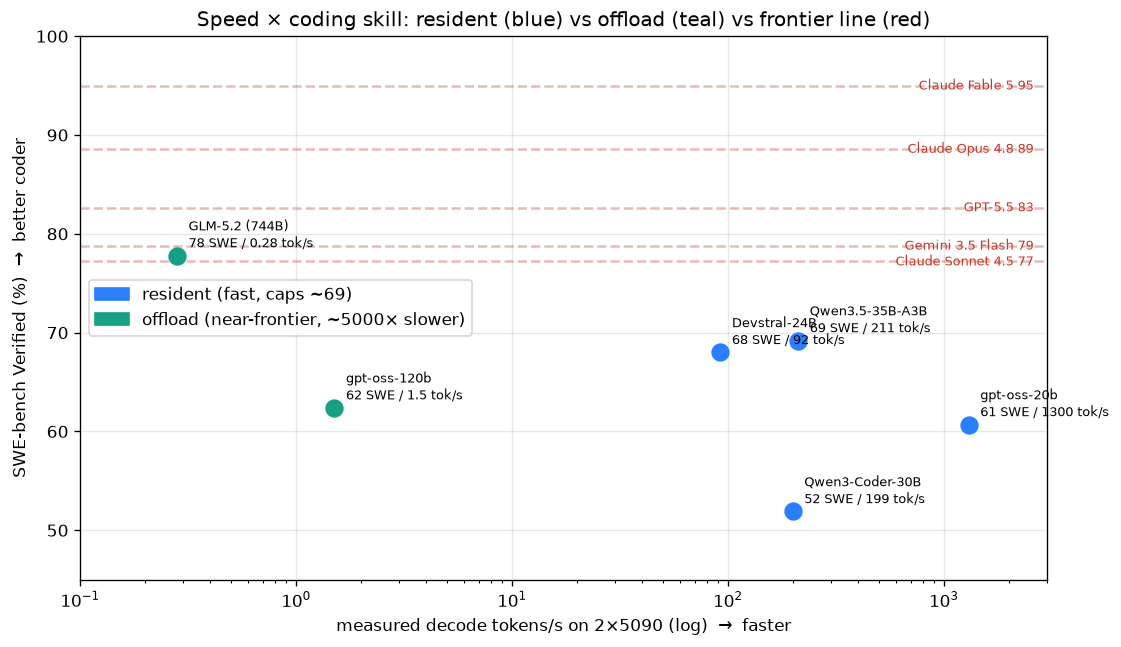

In [7]:
fig, ax = plt.subplots(figsize=(9.5, 5.5))
for lbl, (tps, swe, kind) in RUNNABLE_QUALITY.items():
    color = OFFLOAD_COLOR if kind == "offload" else LOCAL_COLOR
    ax.scatter(tps, swe, s=100, color=color, zorder=3)
    ax.annotate(f"{lbl}\n{swe:.0f} SWE / {tps:g} tok/s", (tps, swe), textcoords="offset points", xytext=(7, 5), fontsize=8)
for name, (s, _, kind) in SWEBENCH.items():
    if kind == "anchor":
        ax.axhline(s, ls="--", color=ANCHOR_COLOR, alpha=0.35)
        ax.text(2600, s, f"{name} {s:.0f}", color=ANCHOR_COLOR, fontsize=7.5, va="center", ha="right")
ax.set_xscale("log")
ax.set_xlim(0.1, 3000)
ax.set_ylim(45, 100)
ax.set_xlabel("measured decode tokens/s on 2×5090 (log)  →  faster")
ax.set_ylabel("SWE-bench Verified (%)  →  better coder")
ax.set_title("Speed × coding skill: resident (blue) vs offload (teal) vs frontier line (red)")
ax.legend(
    handles=[
        Patch(color=LOCAL_COLOR, label="resident (fast, caps ~69)"),
        Patch(color=OFFLOAD_COLOR, label="offload (near-frontier, ~5000× slower)"),
    ],
    loc="center left",
)
fig.tight_layout()
fig.savefig("fig4_pareto.png", bbox_inches="tight")

## 5. Reasoning evals (where models report them)

Coding specialists (Qwen3-Coder, Devstral) mostly don't publish GPQA/AIME, so
coverage is sparse — only the reasoning-capable models appear.

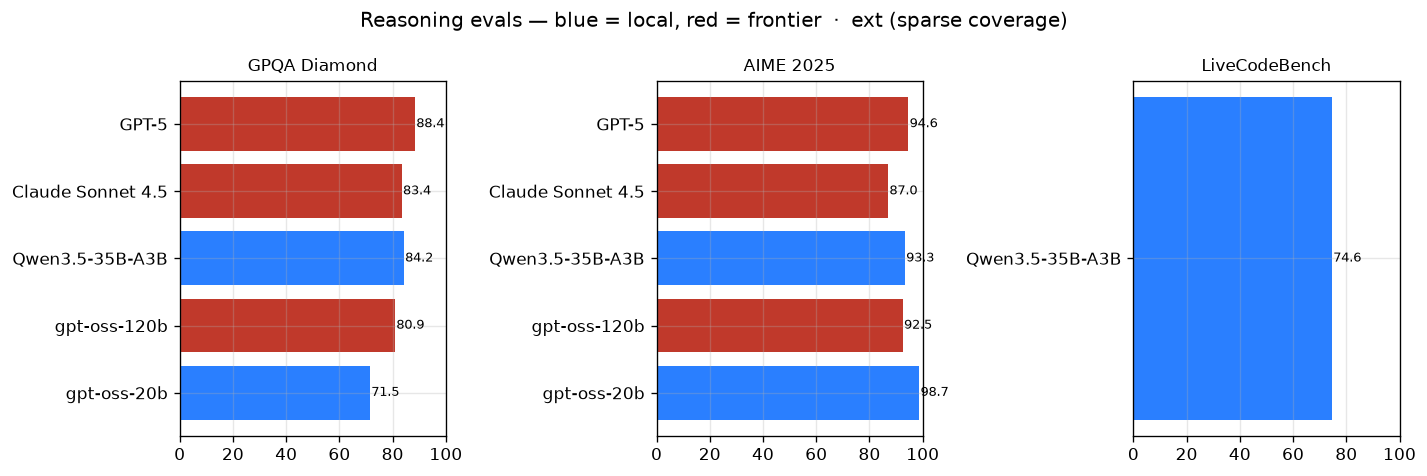

In [8]:
fig, axes = plt.subplots(1, len(REASONING), figsize=(12, 4), sharey=False)
for ax, (metric, d) in zip(axes, REASONING.items()):
    names = list(d.keys())
    vals = list(d.values())
    cols = [LOCAL_COLOR if n in {"gpt-oss-20b", "Qwen3.5-35B-A3B"} else ANCHOR_COLOR for n in names]
    ax.barh(names, vals, color=cols)
    for i, v in enumerate(vals):
        ax.text(v + 0.5, i, f"{v:.1f}", va="center", fontsize=7.5)
    ax.set_title(metric, fontsize=10)
    ax.set_xlim(0, 100)
fig.suptitle("Reasoning evals — blue = local, red = frontier  ·  ext (sparse coverage)")
fig.tight_layout()
fig.savefig("fig5_reasoning.png", bbox_inches="tight")

## Sources

Every eval number above traces to one of these (printed with the run):

In [9]:
for k, v in SOURCES.items():
    print(f"{k:12s} {v}")
print("\nEval provenance: SWE-bench self-reports are scaffold-dependent; vals.ai is")
print("an independent leaderboard (2026-07-17). Numbers are indicative, not exact-comparable.")

qwen3coder   https://huggingface.co/Qwen/Qwen3-Coder-30B-A3B-Instruct
gptoss       https://arxiv.org/abs/2508.10925
qwen35       https://huggingface.co/Qwen/Qwen3.5-35B-A3B
devstral     https://mistral.ai/news/devstral-2-vibe-cli/
valsai_swe   https://www.vals.ai/benchmarks/swebench
gpt5         https://openai.com/index/introducing-gpt-5/
sonnet45     https://www.anthropic.com/news/claude-sonnet-4-5
runs         cluster/docs/inference/runs/  (E1–E5, measured on 2×5090)
glm52        https://venturebeat.com/technology/z-ais-open-weights-glm-5-2-beats-gpt-5-5-on-multiple-long-horizon-coding-benchmarks-for-1-6th-the-cost
glm52_colibri cluster/docs/inference/runs/2026-07-14_glm52_colibri/  (measured 0.28 tok/s)
oss120       https://arxiv.org/abs/2508.10925

Eval provenance: SWE-bench self-reports are scaffold-dependent; vals.ai is
an independent leaderboard (2026-07-17). Numbers are indicative, not exact-comparable.
